<a href="https://colab.research.google.com/github/SelviAnbarasu/International-Dept-Analyst/blob/main/International_Debt_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
df = pd.read_csv("IDS_ALLCountries_Data.csv", encoding="latin1")

df.head()

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,2000,2001,2002,2003,...,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
0,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.DPPG,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.OFFT,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.PRVT,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.DPPG,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.OFFT,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(46507, 39)

In [4]:
df.columns

Index(['Country Name', 'Country Code', 'Counterpart-Area Name',
       'Counterpart-Area Code', 'Series Name', 'Series Code', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028',
       '2029', '2030', '2031', '2032'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
Country Name,0
Country Code,0
Counterpart-Area Name,0
Counterpart-Area Code,0
Series Name,0
Series Code,0
2000,9612
2001,9589
2002,9711
2003,10008


In [6]:
#Remove unwanted columns
df = df.drop(columns=[
    'Country Code',
    'Counterpart-Area Name',
    'Counterpart-Area Code',
    'Series Code'
])

df.head()

,Country Name,Series Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
0,Afghanistan,Average grace period on new external debt comm...,NaN,NaN,NaN,NaN,NaN,NaN,10.2500,8.0833,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Average grace period on new external debt comm...,NaN,NaN,NaN,NaN,NaN,NaN,10.2500,8.0833,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,Average grace period on new external debt comm...,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Average grant element on new external debt com...,NaN,NaN,NaN,NaN,NaN,NaN,50.6176,43.0248,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Average grant element on new external debt com...,NaN,NaN,NaN,NaN,NaN,NaN,50.6176,43.0248,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Wide to Long format
df_long = df.melt(
    id_vars=['Country Name', 'Series Name'],
    var_name='Year',
    value_name='Debt'
)

df_long.head()

,Country Name,Series Name,Year,Debt
0,Afghanistan,Average grace period on new external debt comm...,2000,NaN
1,Afghanistan,Average grace period on new external debt comm...,2000,NaN
2,Afghanistan,Average grace period on new external debt comm...,2000,NaN
3,Afghanistan,Average grant element on new external debt com...,2000,NaN
4,Afghanistan,Average grant element on new external debt com...,2000,NaN


In [8]:
df_long.isnull().sum()

,0
Country Name,0
Series Name,0
Year,0
Debt,534092


In [9]:
#Remove null values
df_long = df_long.dropna()

df_long.isnull().sum()

,0
Country Name,0
Series Name,0
Year,0
Debt,0


In [10]:
#Rename columns
df_long.columns = [
    'country_name',
    'indicator_name',
    'year',
    'debt'
]

df_long.head()

,country_name,indicator_name,year,debt
297,Albania,Average grace period on new external debt comm...,2000,10.5454
298,Albania,Average grace period on new external debt comm...,2000,10.5454
299,Albania,Average grace period on new external debt comm...,2000,0.0000
300,Albania,Average grant element on new external debt com...,2000,25.7609
301,Albania,Average grant element on new external debt com...,2000,25.7609


In [11]:
#Data type conversion
df_long['debt'] = pd.to_numeric(df_long['debt'], errors='coerce')
df_long = df_long.dropna()
df_long = df_long.drop_duplicates()

df_long.shape

(1000639, 4)

In [12]:
#Metadata load
country_meta = pd.read_csv("IDS_CountryMetaData.csv", encoding="latin1")

country_meta.head()

,Code,Long Name,Income Group,Region,Lending category,Other groups,Currency Unit,Latest population census,Latest household survey,Special Notes,...,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,2-alpha code,WB-2 code,Table Name,Short Name
0,AFG,Islamic State of Afghanistan,Low income,Middle East & North Africa,IDA,HIPC,Afghan afghani,1979,Multiple Indicator Cluster Survey 2022-2023,The reporting period for national accounts dat...,...,"Integrated household survey (IHS), 2016/17",NaN,NaN,NaN,2018.0,2000.0,AF,AF,Afghanistan,Afghanistan
1,ALB,Republic of Albania,Upper middle income,Europe & Central Asia,IBRD,NaN,Albanian lek,2023,Demographic and Health Survey 2017 - 2018,NaN,...,Living Standards Measurement Study Survey (LSM...,Yes,2012,2013.0,2018.0,2006.0,AL,AL,Albania,Albania
2,DZA,People's Democratic Republic of Algeria,Upper middle income,Middle East & North Africa,IBRD,NaN,Algerian dinar,2022,Multiple Indicator Cluster Survey 2018-2019,NaN,...,"Integrated household survey (IHS), 2011",NaN,NaN,2010.0,2017.0,2012.0,DZ,DZ,Algeria,Algeria
3,AGO,People's Republic of Angola,Lower middle income,Sub-Saharan Africa,IBRD,NaN,Angolan kwanza,2014,Demographic and Health Survey 2015/16,The World Bank systematically assesses the app...,...,"Integrated household survey (IHS), 2008/09",NaN,NaN,NaN,2018.0,2005.0,AO,AO,Angola,Angola
4,ARG,Argentine Republic,Upper middle income,Latin America & Caribbean,IBRD,NaN,Argentine peso,2022,Multiple Indicator Cluster Survey 2019-2020,The World Bank systematically assesses the app...,...,"Integrated household survey (IHS), 2016",Yes,2008,2002.0,2018.0,2011.0,AR,AR,Argentina,Argentina


In [13]:
#Metadata null check
country_meta.isnull().sum()

,0
Code,0
Long Name,0
Income Group,15
Region,14
Lending category,14
Other groups,94
Currency Unit,14
Latest population census,16
Latest household survey,14
Special Notes,74


In [14]:
country_meta_clean = country_meta[[    'Table Name',
    'Region',
    'Income Group',
    'Lending category',
    'Currency Unit',
    'Other groups',
    'External debt Reporting status',
    '2-alpha code',
    'WB-2 code',
    'Short Name'
]].copy()

country_meta_clean.columns = [
    'country_name',
    'region',
    'income_group',
    'lending_category',
    'currency_unit',
    'other_groups',
    'external_debt_reporting_status',
    'alpha_code',
    'wb_code',
    'short_name'
]
country_meta_clean.head()

,country_name,region,income_group,lending_category,currency_unit,other_groups,external_debt_reporting_status,alpha_code,wb_code,short_name
0,Afghanistan,Middle East & North Africa,Low income,IDA,Afghan afghani,HIPC,Estimate,AF,AF,Afghanistan
1,Albania,Europe & Central Asia,Upper middle income,IBRD,Albanian lek,NaN,Actual,AL,AL,Albania
2,Algeria,Middle East & North Africa,Upper middle income,IBRD,Algerian dinar,NaN,Actual,DZ,DZ,Algeria
3,Angola,Sub-Saharan Africa,Lower middle income,IBRD,Angolan kwanza,NaN,Actual,AO,AO,Angola
4,Argentina,Latin America & Caribbean,Upper middle income,IBRD,Argentine peso,NaN,Actual,AR,AR,Argentina


In [15]:
country_meta_clean.isnull().sum()

,0
country_name,0
region,14
income_group,15
lending_category,14
currency_unit,14
other_groups,94
external_debt_reporting_status,14
alpha_code,0
wb_code,0
short_name,0


In [16]:
#Clean metadata
country_meta_clean = country_meta_clean.dropna()

country_meta_clean = country_meta_clean.rename(columns={
    'Table Name': 'country_name',
    'Region': 'region',
    'Income Group': 'income_group',
    'Lending category': 'lending_category'
})

country_meta_clean.head()

,country_name,region,income_group,lending_category,currency_unit,other_groups,external_debt_reporting_status,alpha_code,wb_code,short_name
0,Afghanistan,Middle East & North Africa,Low income,IDA,Afghan afghani,HIPC,Estimate,AF,AF,Afghanistan
10,Benin,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
12,Bolivia,Latin America & Caribbean,Lower middle income,IBRD,Bolivian Boliviano,HIPC,Actual,BO,BO,"Bolivia, Plurinational State of"
16,Burkina Faso,Sub-Saharan Africa,Low income,IDA,West African CFA franc,HIPC,Actual,BF,BF,Burkina Faso
17,Burundi,Sub-Saharan Africa,Low income,IDA,Burundi franc,HIPC,Actual,BI,BI,Burundi


In [17]:
#Merge main data + metadata
df_final = pd.merge(
    df_long,
    country_meta_clean,
    on='country_name',
    how='left'
)

df_final.head()

,country_name,indicator_name,year,debt,region,income_group,lending_category,currency_unit,other_groups,external_debt_reporting_status,alpha_code,wb_code,short_name
0,Albania,Average grace period on new external debt comm...,2000,10.5454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,Average grace period on new external debt comm...,2000,10.5454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,Average grace period on new external debt comm...,2000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,Average grant element on new external debt com...,2000,25.7609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Albania,Average grant element on new external debt com...,2000,25.7609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
#Final null check
df_final.isnull().sum()

,0
country_name,0
indicator_name,0
year,0
debt,0
region,752033
income_group,752033
lending_category,752033
currency_unit,752033
other_groups,752033
external_debt_reporting_status,752033


In [19]:
df_final = df_final.dropna() #Cleaning

df_final.isnull().sum()

,0
country_name,0
indicator_name,0
year,0
debt,0
region,0
income_group,0
lending_category,0
currency_unit,0
other_groups,0
external_debt_reporting_status,0


In [20]:
#Save final CSV
df_final.to_csv("final_debt_data_with_metadata.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [21]:
df_final.describe()

,debt
count,2.486060e+05
mean,3.018378e+08
std,2.430582e+09
min,-7.411020e+09
25%,1.801900e+00
50%,7.738988e+06
75%,9.357964e+07
max,8.410000e+11


In [22]:
df_final.nunique()

,0
country_name,28
indicator_name,563
year,33
debt,115163
region,4
income_group,3
lending_category,3
currency_unit,21
other_groups,1
external_debt_reporting_status,3


In [23]:
df_final.columns

Index(['country_name', 'indicator_name', 'year', 'debt', 'region',
       'income_group', 'lending_category', 'currency_unit', 'other_groups',
       'external_debt_reporting_status', 'alpha_code', 'wb_code',
       'short_name'],
      dtype='object')

In [24]:
df_final['debt'].sum() #EDA Outputs

np.float64(75038699868202.2)

In [25]:
#Top 10 countries
top_countries = df_final.groupby('country_name')['debt'].sum().sort_values(ascending=False).head(10)

top_countries

,debt
country_name,
Ghana,1.071276e+13
Mozambique,8.765469e+12
Bolivia,5.359018e+12
Cameroon,5.194022e+12
"Congo, Dem. Rep.",4.997821e+12
Honduras,4.220887e+12
Nicaragua,3.960333e+12
Mali,3.748617e+12
"Congo, Rep.",3.111782e+12


In [26]:
#Top indicators
top_indicators = df_final.groupby('indicator_name')['debt'].sum().sort_values(ascending=False).head(10)

top_indicators

,debt
indicator_name,
GNI (current US$),7.839628e+12
"External debt stocks, total (DOD, current US$)",3.833710e+12
"External debt stocks, long-term (DOD, current US$)",3.299331e+12
"Imports of goods, services and primary income (current US$)",3.211123e+12
"Exports of goods, services and primary income (current US$)",2.244577e+12
"External debt stocks, public and publicly guaranteed (PPG) (DOD, current US$)",2.234354e+12
"External debt stocks, long-term public sector (DOD, current US$)",2.233477e+12
"External debt stocks, public sector (PPG) (DOD, current US$)",2.233123e+12
"Total reserves (includes gold, current US$)",2.184274e+12


In [27]:
#Region-wise debt
region_debt = df_final.groupby('region')['debt'].sum().sort_values(ascending=False)

region_debt

,debt
region,
Sub-Saharan Africa,5.551599e+13
Latin America & Caribbean,1.591735e+13
Europe & Central Asia,2.383729e+12
Middle East & North Africa,1.221629e+12


In [28]:
#Income group-wise debt
income_debt = df_final.groupby('income_group')['debt'].sum().sort_values(ascending=False)

income_debt

,debt
income_group,
Lower middle income,4.265021e+13
Low income,3.134366e+13
High income,1.044832e+12


Python charts

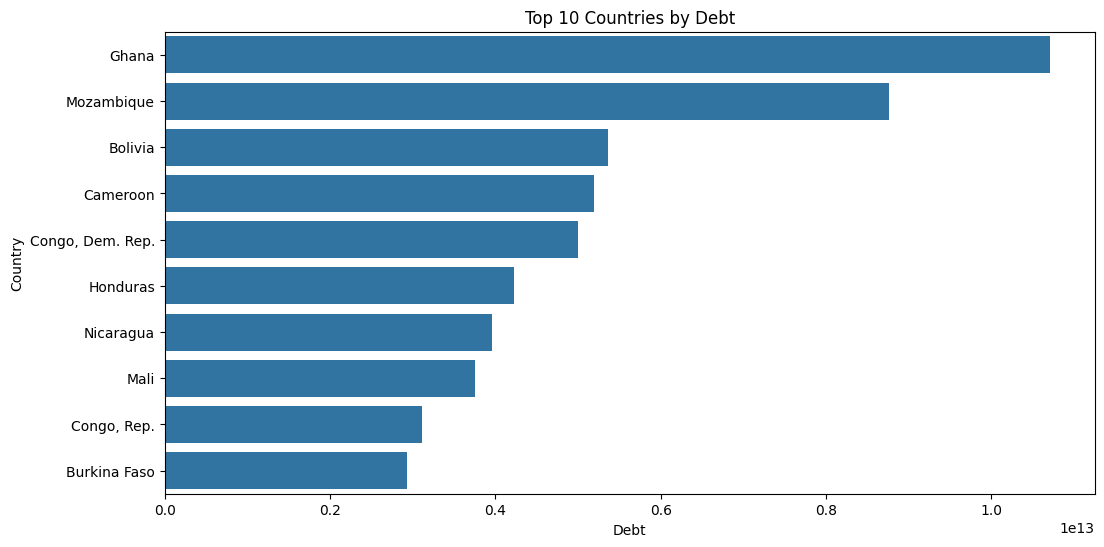

In [29]:
#Top countries chart
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Debt")
plt.xlabel("Debt")
plt.ylabel("Country")
plt.show()

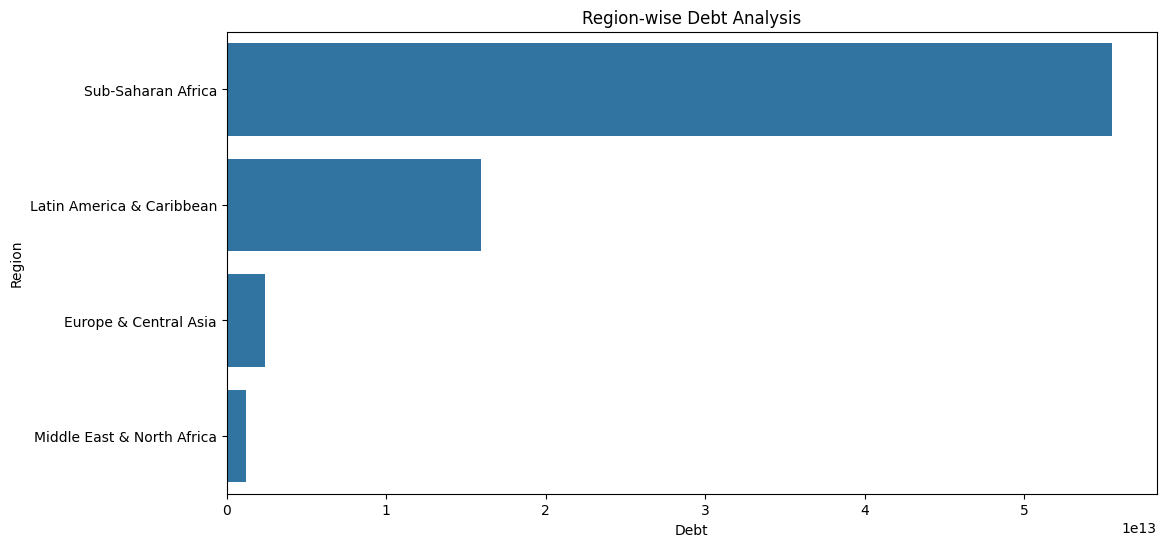

In [30]:
#Region chart
plt.figure(figsize=(12,6))
sns.barplot(x=region_debt.values, y=region_debt.index)
plt.title("Region-wise Debt Analysis")
plt.xlabel("Debt")
plt.ylabel("Region")
plt.show()

In [31]:
conn = sqlite3.connect(":memory:") #SQL

df_final.to_sql("debt_data", conn, index=False, if_exists="replace")

248606

In [32]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_records
FROM debt_data;
""", conn)

,total_records
0,248606


All 30 SQL Queries

In [33]:
print("Query 1: Count Total Records")

pd.read_sql_query("""
SELECT COUNT(*) AS total_records
FROM debt_data;
""", conn)

Query 1: Count Total Records


,total_records
0,248606


In [34]:
# 2. Retrieve all distinct country names
pd.read_sql_query("""
SELECT DISTINCT country_name FROM debt_data;
""", conn)

,country_name
0,Benin
1,Bolivia
2,Burkina Faso
3,Burundi
4,Cameroon
5,Central African Republic
6,Chad
7,Comoros
8,"Congo, Dem. Rep."
9,"Congo, Rep."


In [35]:
# 3. Count total number of countries
pd.read_sql_query("""
SELECT COUNT(DISTINCT country_name) AS total_countries FROM debt_data;
""", conn)

,total_countries
0,28


In [36]:
# 4. Find total number of indicators
pd.read_sql_query("""
SELECT COUNT(DISTINCT indicator_name) AS total_indicators FROM debt_data;
""", conn)

,total_indicators
0,563


In [37]:
# 5. Display first 10 records
pd.read_sql_query("""
SELECT * FROM debt_data LIMIT 10;
""", conn)

,country_name,indicator_name,year,debt,region,income_group,lending_category,currency_unit,other_groups,external_debt_reporting_status,alpha_code,wb_code,short_name
0,Benin,Average grace period on new external debt comm...,2000,8.2981,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
1,Benin,Average grace period on new external debt comm...,2000,8.2981,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
2,Benin,Average grace period on new external debt comm...,2000,0.0000,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
3,Benin,Average grant element on new external debt com...,2000,39.9159,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
4,Benin,Average grant element on new external debt com...,2000,39.9159,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
5,Benin,Average grant element on new external debt com...,2000,0.0000,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
6,Benin,Average interest on new external debt commitme...,2000,1.8708,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
7,Benin,Average interest on new external debt commitme...,2000,1.8708,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
8,Benin,Average interest on new external debt commitme...,2000,0.0000,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
9,Benin,Average maturity on new external debt commitme...,2000,33.2315,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin


In [38]:
# 6. Calculate total global debt
pd.read_sql_query("""
SELECT SUM(debt) AS total_global_debt FROM debt_data;
""", conn)

,total_global_debt
0,7.503870e+13


In [39]:
# 7. List all unique indicator names
pd.read_sql_query("""
SELECT DISTINCT indicator_name FROM debt_data;
""", conn)

,indicator_name
0,Average grace period on new external debt comm...
1,Average grace period on new external debt comm...
2,Average grace period on new external debt comm...
3,Average grant element on new external debt com...
4,Average grant element on new external debt com...
...,...
558,Present value of external debt (current US$)
559,"Present value of debt (% of exports of goods, ..."
560,Present value of debt (% of GNI)
561,"OPS, bonds (NFL, current US$)"


In [40]:
# 8. Find number of records for each country
pd.read_sql_query("""
SELECT country_name, COUNT(*) AS record_count
FROM debt_data
GROUP BY country_name;
""", conn)

,country_name,record_count
0,Afghanistan,5268
1,Benin,8472
2,Bolivia,11648
3,Burkina Faso,9268
4,Burundi,7728
5,Cameroon,10237
6,Central African Republic,7966
7,Chad,8400
8,Comoros,6688
9,"Congo, Dem. Rep.",9005


In [41]:
# 9. Display records where debt is greater than 1 billion USD
pd.read_sql_query("""
SELECT * FROM debt_data
WHERE debt > 1000000000;
""", conn)

,country_name,indicator_name,year,debt,region,income_group,lending_category,currency_unit,other_groups,external_debt_reporting_status,alpha_code,wb_code,short_name
0,Benin,"External debt stocks, general government secto...",2000,1.238723e+09,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
1,Benin,"External debt stocks, long-term (DOD, current ...",2000,1.322604e+09,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
2,Benin,"External debt stocks, long-term public sector ...",2000,1.245905e+09,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
3,Benin,"External debt stocks, public and publicly guar...",2000,1.245905e+09,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
4,Benin,"External debt stocks, public sector (PPG) (DOD...",2000,1.245905e+09,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15268,Mozambique,"PNG, commercial banks and other creditors (TDS...",2032,2.465993e+09,Sub-Saharan Africa,Low income,IDA,New Mozambican metical,HIPC,Actual,MZ,MZ,Mozambique
15269,Mozambique,"Principal repayments on external debt, long-te...",2032,2.746384e+09,Sub-Saharan Africa,Low income,IDA,New Mozambican metical,HIPC,Actual,MZ,MZ,Mozambique
15270,Mozambique,"Principal repayments on external debt, private...",2032,2.326408e+09,Sub-Saharan Africa,Low income,IDA,New Mozambican metical,HIPC,Actual,MZ,MZ,Mozambique
15271,Nicaragua,"Debt service on external debt, long-term (TDS,...",2032,1.010494e+09,Latin America & Caribbean,Lower middle income,IDA,Nicaraguan gold cordoba,HIPC,Actual,NI,NI,Nicaragua


In [42]:
# 10. Find min, max, average debt values
pd.read_sql_query("""
SELECT MIN(debt) AS min_debt,
       MAX(debt) AS max_debt,
       AVG(debt) AS avg_debt
FROM debt_data;
""", conn)

,min_debt,max_debt,avg_debt
0,-7.411020e+09,8.410000e+11,3.018378e+08


In [43]:
# 11. Find total debt for each country
pd.read_sql_query("""
SELECT country_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY country_name;
""", conn)

,country_name,total_debt
0,Afghanistan,1.221629e+12
1,Benin,2.494198e+12
2,Bolivia,5.359018e+12
3,Burkina Faso,2.930382e+12
4,Burundi,4.601014e+11
5,Cameroon,5.194022e+12
6,Central African Republic,3.548743e+11
7,Chad,1.564235e+12
8,Comoros,1.640169e+11
9,"Congo, Dem. Rep.",4.997821e+12


In [44]:
# 12. Top 10 countries with highest total debt
pd.read_sql_query("""
SELECT country_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY country_name
ORDER BY total_debt DESC
LIMIT 10;
""", conn)

,country_name,total_debt
0,Ghana,1.071276e+13
1,Mozambique,8.765469e+12
2,Bolivia,5.359018e+12
3,Cameroon,5.194022e+12
4,"Congo, Dem. Rep.",4.997821e+12
5,Honduras,4.220887e+12
6,Nicaragua,3.960333e+12
7,Mali,3.748617e+12
8,"Congo, Rep.",3.111782e+12
9,Burkina Faso,2.930382e+12


In [45]:
# 13. Average debt per country
pd.read_sql_query("""
SELECT country_name, AVG(debt) AS average_debt
FROM debt_data
GROUP BY country_name;
""", conn)

,country_name,average_debt
0,Afghanistan,2.318962e+08
1,Benin,2.944049e+08
2,Bolivia,4.600806e+08
3,Burkina Faso,3.161828e+08
4,Burundi,5.953694e+07
5,Cameroon,5.073773e+08
6,Central African Republic,4.454862e+07
7,Chad,1.862185e+08
8,Comoros,2.452406e+07
9,"Congo, Dem. Rep.",5.550052e+08


In [46]:
# 14. Total debt for each indicator
pd.read_sql_query("""
SELECT indicator_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY indicator_name;
""", conn)

,indicator_name,total_debt
0,Average grace period on new external debt comm...,4.469385e+03
1,Average grace period on new external debt comm...,4.502847e+03
2,Average grace period on new external debt comm...,6.832502e+02
3,Average grant element on new external debt com...,2.354803e+04
4,Average grant element on new external debt com...,2.458830e+04
...,...,...
558,"Undisbursed external debt, official creditors ...",8.797623e+11
559,"Undisbursed external debt, private creditors (...",7.315326e+10
560,"Undisbursed external debt, total (UND, current...",9.529156e+11
561,"Use of IMF credit (DOD, current US$)",1.395063e+11


In [47]:
# 15. Indicator contributing highest total debt
pd.read_sql_query("""
SELECT indicator_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY indicator_name
ORDER BY total_debt DESC
LIMIT 1;
""", conn)

,indicator_name,total_debt
0,GNI (current US$),7.839628e+12


In [48]:
# 16. Country with lowest total debt
pd.read_sql_query("""
SELECT country_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY country_name
ORDER BY total_debt ASC
LIMIT 1;
""", conn)

,country_name,total_debt
0,Comoros,1.640169e+11


In [49]:
# 17. Total debt for each country and indicator combination
pd.read_sql_query("""
SELECT country_name, indicator_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY country_name, indicator_name;
""", conn)

,country_name,indicator_name,total_debt
0,Afghanistan,Average grace period on new external debt comm...,1.036971e+02
1,Afghanistan,Average grace period on new external debt comm...,1.036971e+02
2,Afghanistan,Average grace period on new external debt comm...,0.000000e+00
3,Afghanistan,Average grant element on new external debt com...,3.921329e+02
4,Afghanistan,Average grant element on new external debt com...,3.921329e+02
...,...,...,...
11473,Niger,"Undisbursed external debt, official creditors ...",4.136919e+10
11474,Niger,"Undisbursed external debt, private creditors (...",2.580228e+08
11475,Niger,"Undisbursed external debt, total (UND, current...",4.162721e+10
11476,Niger,"Use of IMF credit (DOD, current US$)",4.485910e+09


In [50]:
# 18. Count how many indicators each country has
pd.read_sql_query("""
SELECT country_name,
       COUNT(DISTINCT indicator_name) AS indicator_count
FROM debt_data
GROUP BY country_name;
""", conn)

,country_name,indicator_count
0,Afghanistan,297
1,Benin,407
2,Bolivia,480
3,Burkina Faso,384
4,Burundi,393
5,Cameroon,451
6,Central African Republic,365
7,Chad,371
8,Comoros,307
9,"Congo, Dem. Rep.",420


In [51]:
# 19. Countries whose total debt is above global average
pd.read_sql_query("""
SELECT country_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY country_name
HAVING SUM(debt) > (
    SELECT AVG(country_total)
    FROM (
        SELECT SUM(debt) AS country_total
        FROM debt_data
        GROUP BY country_name
    )
);
""", conn)

,country_name,total_debt
0,Bolivia,5.359018e+12
1,Burkina Faso,2.930382e+12
2,Cameroon,5.194022e+12
3,"Congo, Dem. Rep.",4.997821e+12
4,"Congo, Rep.",3.111782e+12
5,Ghana,1.071276e+13
6,Honduras,4.220887e+12
7,Mali,3.748617e+12
8,Mozambique,8.765469e+12
9,Nicaragua,3.960333e+12


In [52]:
# 20. Rank countries based on total debt
pd.read_sql_query("""
SELECT country_name,
       SUM(debt) AS total_debt,
       RANK() OVER (ORDER BY SUM(debt) DESC) AS debt_rank
FROM debt_data
GROUP BY country_name;
""", conn)

,country_name,total_debt,debt_rank
0,Ghana,1.071276e+13,1
1,Mozambique,8.765469e+12,2
2,Bolivia,5.359018e+12,3
3,Cameroon,5.194022e+12,4
4,"Congo, Dem. Rep.",4.997821e+12,5
5,Honduras,4.220887e+12,6
6,Nicaragua,3.960333e+12,7
7,Mali,3.748617e+12,8
8,"Congo, Rep.",3.111782e+12,9
9,Burkina Faso,2.930382e+12,10


In [53]:
# 21. Top 5 indicators contributing most to global debt
pd.read_sql_query("""
SELECT indicator_name, SUM(debt) AS total_debt
FROM debt_data
GROUP BY indicator_name
ORDER BY total_debt DESC
LIMIT 5;
""", conn)

,indicator_name,total_debt
0,GNI (current US$),7.839628e+12
1,"External debt stocks, total (DOD, current US$)",3.833710e+12
2,"External debt stocks, long-term (DOD, current ...",3.299331e+12
3,"Imports of goods, services and primary income ...",3.211123e+12
4,"Exports of goods, services and primary income ...",2.244577e+12


In [54]:
# 22. Percentage contribution of each country to total global debt
pd.read_sql_query("""
SELECT country_name,
       SUM(debt) AS total_debt,
       ROUND((SUM(debt) * 100.0 / (SELECT SUM(debt) FROM debt_data)), 2) AS percentage_contribution
FROM debt_data
GROUP BY country_name
ORDER BY percentage_contribution DESC;
""", conn)

,country_name,total_debt,percentage_contribution
0,Ghana,1.071276e+13,14.28
1,Mozambique,8.765469e+12,11.68
2,Bolivia,5.359018e+12,7.14
3,Cameroon,5.194022e+12,6.92
4,"Congo, Dem. Rep.",4.997821e+12,6.66
5,Honduras,4.220887e+12,5.62
6,Nicaragua,3.960333e+12,5.28
7,Mali,3.748617e+12,5.00
8,"Congo, Rep.",3.111782e+12,4.15
9,Burkina Faso,2.930382e+12,3.91


In [55]:
# 23. Top 3 countries for each indicator based on debt
pd.read_sql_query("""
SELECT indicator_name, country_name, total_debt
FROM (
    SELECT indicator_name,
           country_name,
           SUM(debt) AS total_debt,
           RANK() OVER (
               PARTITION BY indicator_name
               ORDER BY SUM(debt) DESC
           ) AS rank_no
    FROM debt_data
    GROUP BY indicator_name, country_name
)
WHERE rank_no <= 3;
""", conn)

,indicator_name,country_name,total_debt
0,Average grace period on new external debt comm...,Malawi,2.062057e+02
1,Average grace period on new external debt comm...,Honduras,2.047472e+02
2,Average grace period on new external debt comm...,Mozambique,2.031464e+02
3,Average grace period on new external debt comm...,Malawi,2.062057e+02
4,Average grace period on new external debt comm...,Mozambique,2.046394e+02
...,...,...,...
1896,"Use of IMF credit (DOD, current US$)","Congo, Dem. Rep.",1.790531e+10
1897,"Use of IMF credit (DOD, current US$)",Cameroon,1.068677e+10
1898,"Use of IMF credit and SDR allocations (DOD, cu...","Congo, Dem. Rep.",3.622665e+10
1899,"Use of IMF credit and SDR allocations (DOD, cu...",Ghana,3.464078e+10


In [56]:
# 24. Difference between max and min debt for each country
pd.read_sql_query("""
SELECT country_name,
       MAX(debt) AS max_debt,
       MIN(debt) AS min_debt,
       MAX(debt) - MIN(debt) AS debt_difference
FROM debt_data
GROUP BY country_name;
""", conn)

,country_name,max_debt,min_debt,debt_difference
0,Afghanistan,2.055967e+10,-5.150162e+09,2.570983e+10
1,Benin,2.128026e+10,-1.705464e+09,2.298572e+10
2,Bolivia,4.830578e+10,-1.936209e+09,5.024199e+10
3,Burkina Faso,2.224113e+10,-4.055534e+09,2.629666e+10
4,Burundi,3.352709e+09,-8.316993e+08,4.184409e+09
5,Cameroon,5.040584e+10,-4.281531e+09,5.468737e+10
6,Central African Republic,2.917117e+09,-5.194096e+08,3.436527e+09
7,Chad,2.041450e+10,-3.823558e+09,2.423806e+10
8,Comoros,1.553985e+09,-1.097495e+08,1.663734e+09
9,"Congo, Dem. Rep.",6.839586e+10,-7.411020e+09,7.580688e+10


In [57]:
conn.execute("DROP VIEW IF EXISTS top_10_countries")

In [58]:
# Query 25: Create view for top 10 countries with highest debt

conn.execute("""
DROP VIEW IF EXISTS top_10_countries;
""")

conn.execute("""
CREATE VIEW top_10_countries AS
SELECT country_name,
       SUM(debt) AS total_debt
FROM debt_data
GROUP BY country_name
ORDER BY total_debt DESC
LIMIT 10;
""")

print("View created successfully")

View created successfully


In [59]:
pd.read_sql_query("""
SELECT * FROM top_10_countries;
""", conn)

,country_name,total_debt
0,Ghana,1.071276e+13
1,Mozambique,8.765469e+12
2,Bolivia,5.359018e+12
3,Cameroon,5.194022e+12
4,"Congo, Dem. Rep.",4.997821e+12
5,Honduras,4.220887e+12
6,Nicaragua,3.960333e+12
7,Mali,3.748617e+12
8,"Congo, Rep.",3.111782e+12
9,Burkina Faso,2.930382e+12


In [60]:
# 26. Categorize countries into High, Medium, Low debt
pd.read_sql_query("""
SELECT country_name,
       SUM(debt) AS total_debt,
       CASE
           WHEN SUM(debt) >= 1000000000000 THEN 'High Debt'
           WHEN SUM(debt) >= 100000000000 THEN 'Medium Debt'
           ELSE 'Low Debt'
       END AS debt_category
FROM debt_data
GROUP BY country_name;
""", conn)

,country_name,total_debt,debt_category
0,Afghanistan,1.221629e+12,High Debt
1,Benin,2.494198e+12,High Debt
2,Bolivia,5.359018e+12,High Debt
3,Burkina Faso,2.930382e+12,High Debt
4,Burundi,4.601014e+11,Medium Debt
5,Cameroon,5.194022e+12,High Debt
6,Central African Republic,3.548743e+11,Medium Debt
7,Chad,1.564235e+12,High Debt
8,Comoros,1.640169e+11,Medium Debt
9,"Congo, Dem. Rep.",4.997821e+12,High Debt


In [61]:
# 27. Cumulative debt by country using window function
pd.read_sql_query("""
SELECT country_name,
       year,
       SUM(debt) AS yearly_debt,
       SUM(SUM(debt)) OVER (
           PARTITION BY country_name
           ORDER BY year
       ) AS cumulative_debt
FROM debt_data
GROUP BY country_name, year;
""", conn)

,country_name,year,yearly_debt,cumulative_debt
0,Afghanistan,2006,3.456692e+10,3.456692e+10
1,Afghanistan,2007,5.740144e+10,9.196836e+10
2,Afghanistan,2008,5.797651e+10,1.499449e+11
3,Afghanistan,2009,6.674058e+10,2.166854e+11
4,Afghanistan,2010,6.983335e+10,2.865188e+11
...,...,...,...,...
913,Niger,2028,1.095891e+10,1.733241e+12
914,Niger,2029,1.087852e+10,1.744119e+12
915,Niger,2030,1.015493e+10,1.754274e+12
916,Niger,2031,9.420185e+09,1.763694e+12


In [62]:
# 28. Indicators where average debt is higher than overall average debt
pd.read_sql_query("""
SELECT indicator_name,
       AVG(debt) AS average_debt
FROM debt_data
GROUP BY indicator_name
HAVING AVG(debt) > (
    SELECT AVG(debt) FROM debt_data
);
""", conn)

,indicator_name,average_debt
0,"Commitments, official creditors (COM, current ...",3.655653e+08
1,"Commitments, public and publicly guaranteed (C...",4.553086e+08
2,"Debt service on external debt, long-term (TDS,...",5.155405e+08
3,"Debt service on external debt, private nonguar...",5.488860e+08
4,"Debt service on external debt, total (TDS, cur...",5.509242e+08
...,...,...
59,"Principal repayments on external debt, private...",4.896450e+08
60,"Total reserves (includes gold, current US$)",3.418269e+09
61,"Undisbursed external debt, official creditors ...",1.267669e+09
62,"Undisbursed external debt, total (UND, current...",1.373077e+09


In [63]:
# 29. Countries contributing more than 5% of global debt
pd.read_sql_query("""
SELECT country_name,
       SUM(debt) AS total_debt,
       ROUND((SUM(debt) * 100.0 / (SELECT SUM(debt) FROM debt_data)), 2) AS contribution_percentage
FROM debt_data
GROUP BY country_name
HAVING contribution_percentage > 5
ORDER BY contribution_percentage DESC;
""", conn)

,country_name,total_debt,contribution_percentage
0,Ghana,1.071276e+13,14.28
1,Mozambique,8.765469e+12,11.68
2,Bolivia,5.359018e+12,7.14
3,Cameroon,5.194022e+12,6.92
4,"Congo, Dem. Rep.",4.997821e+12,6.66
5,Honduras,4.220887e+12,5.62
6,Nicaragua,3.960333e+12,5.28


In [64]:
# 30. Most dominant indicator for each country
pd.read_sql_query("""
SELECT country_name, indicator_name, total_debt
FROM (
    SELECT country_name,
           indicator_name,
           SUM(debt) AS total_debt,
           RANK() OVER (
               PARTITION BY country_name
               ORDER BY SUM(debt) DESC
           ) AS rank_no
    FROM debt_data
    GROUP BY country_name, indicator_name
)
WHERE rank_no = 1;
""", conn)

,country_name,indicator_name,total_debt
0,Afghanistan,GNI (current US$),2.940243e+11
1,Benin,GNI (current US$),2.762697e+11
2,Bolivia,GNI (current US$),6.243486e+11
3,Burkina Faso,GNI (current US$),2.823298e+11
4,Burundi,GNI (current US$),5.037085e+10
5,Cameroon,GNI (current US$),7.448400e+11
6,Central African Republic,GNI (current US$),4.824847e+10
7,Chad,GNI (current US$),3.015598e+11
8,Comoros,GNI (current US$),2.379340e+10
9,"Congo, Dem. Rep.",GNI (current US$),7.660250e+11


In [65]:
import pandas as pd

In [66]:
df=pd.read_csv("final_debt_data_with_metadata.csv")

In [67]:
df=pd.read_csv("final_debt_data_with_metadata.csv")

In [68]:
df.head()

,country_name,indicator_name,year,debt,region,income_group,lending_category,currency_unit,other_groups,external_debt_reporting_status,alpha_code,wb_code,short_name
0,Benin,Average grace period on new external debt comm...,2000,8.2981,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
1,Benin,Average grace period on new external debt comm...,2000,8.2981,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
2,Benin,Average grace period on new external debt comm...,2000,0.0000,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
3,Benin,Average grant element on new external debt com...,2000,39.9159,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
4,Benin,Average grant element on new external debt com...,2000,39.9159,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin


In [69]:
df

,country_name,indicator_name,year,debt,region,income_group,lending_category,currency_unit,other_groups,external_debt_reporting_status,alpha_code,wb_code,short_name
0,Benin,Average grace period on new external debt comm...,2000,8.298100e+00,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
1,Benin,Average grace period on new external debt comm...,2000,8.298100e+00,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
2,Benin,Average grace period on new external debt comm...,2000,0.000000e+00,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
3,Benin,Average grant element on new external debt com...,2000,3.991590e+01,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
4,Benin,Average grant element on new external debt com...,2000,3.991590e+01,Sub-Saharan Africa,Lower middle income,IDA,West African CFA franc,HIPC,Actual,BJ,BJ,Benin
...,...,...,...,...,...,...,...,...,...,...,...,...,...
248601,Niger,"PS, official creditors (INT, current US$)",2032,4.546793e+07,Sub-Saharan Africa,Low income,IDA,West African CFA franc,HIPC,Actual,NE,NE,Niger
248602,Niger,"PS, official creditors (TDS, current US$)",2032,4.110105e+08,Sub-Saharan Africa,Low income,IDA,West African CFA franc,HIPC,Actual,NE,NE,Niger
248603,Niger,"PS, private creditors (AMT, current US$)",2032,1.512511e+07,Sub-Saharan Africa,Low income,IDA,West African CFA franc,HIPC,Actual,NE,NE,Niger
248604,Niger,"PS, private creditors (INT, current US$)",2032,4.564927e+06,Sub-Saharan Africa,Low income,IDA,West African CFA franc,HIPC,Actual,NE,NE,Niger


In [70]:
country_meta = pd.read_csv("IDS_CountryMetaData.csv", encoding="latin1")
print(country_meta.columns)

Index(['Code', 'Long Name', 'Income Group', 'Region', 'Lending category',
       'Other groups', 'Currency Unit', 'Latest population census',
       'Latest household survey', 'Special Notes',
       'National accounts base year', 'National accounts reference year',
       'System of National Accounts', 'SNA price valuation',
       'PPP survey years', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data', '2-alpha code', 'WB-2 code',
       'Table Name', 'Short Name'],
      dtype='object')


In [71]:
df.columns

Index(['country_name', 'indicator_name', 'year', 'debt', 'region',
       'income_group', 'lending_category', 'currency_unit', 'other_groups',
       'external_debt_reporting_status', 'alpha_code', 'wb_code',
       'short_name'],
      dtype='object')

In [72]:
df_final.to_csv("final_debt_data_with_metadata.csv", index=False)

In [73]:
from google.colab import files

files.download("final_debt_data_with_metadata.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
df["year"].min(), df["year"].max()

(2000, 2032)

In [75]:
print(df["year"].unique())

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027
 2028 2029 2030 2031 2032]
